# Optimization Space III: How Training Selects a Hypothesis

<br>

## Learning Objectives and Lesson Structure

This notebook isolates the **optimisation space** in the learning setup:

$$
(\mathcal{D},\mathcal{H},\mathcal{O})\mapsto s.
$$

Here $\mathcal{D}$ is the observed evidence, $\mathcal{H}$ is the set of functions available to the learner, $\mathcal{O}$ is the optimisation and selection procedure, and $s$ is the selected solution.

The previous notebooks separated evidence and possibility. The data-space notebook asked what the observed dataset can support. The hypothesis-space notebook asked what behaviours the model class makes available. This notebook asks how training selects one reported member from those available functions.

The central question is:

$$
\text{Given }\mathcal{D}\text{ and }\mathcal{H},\text{ how does training select one solution }s?
$$

Most examples use the two-parameter linear model:

$$
h_{\theta}(x)=\theta_0+\theta_1x,
\qquad
\theta=(\theta_0,\theta_1).
$$

This keeps both spaces visible: the fitted line is shown in data space, while the objective surface is shown in parameter space. Least squares gives a useful direct benchmark for this simple case; gradient descent shows what changes when training follows a finite iterative path.

By the end, students should be able to:

- distinguish candidate functions from the selected solution;
- evaluate a selected function using residuals, losses, risks, and penalties;
- explain how an objective turns fit evaluation into a selection criterion;
- motivate the shift from closed-form least squares to iterative optimisation;
- interpret gradient descent as a finite sequence of selected iterates;
- explain how scaling, curvature, stochasticity, regularisation, initialisation, and stopping rules shape the reported solution.

The notebook is organised around twelve questions:

1. **What is being selected?**
2. **How do we evaluate a fit?**
3. **What objective is being minimised?**
4. **Why move beyond least squares?**
5. **How does gradient descent select an iterate?**
6. **What landscape does the optimiser see?**
7. **How do curvature and conditioning affect the path?**
8. **What changes when updates are stochastic?**
9. **What preference does regularisation add?**
10. **Where can initialisation matter?**
11. **Which iterate is reported?**
12. **How do we audit the optimisation procedure?**

The recurring researcher-facing question is:

$$
\text{What exactly did the training procedure select, and why?}
$$


<br>

### Setup

This setup cell imports the shared optimisation helpers used throughout the notebook. It changes only the Python environment for the demonstrations; each section below chooses its own editable variables, selection rule, and diagnostic display. Look for the same small linear hypothesis space to appear while $\mathcal{O}$ changes.


In [35]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

for module_name in list(sys.modules):
    if module_name.startswith("nextgen2026_mlai_workshops"):
        del sys.modules[module_name]

from nextgen2026_mlai_workshops.optimization_space import (
    configure_optimization_matplotlib,
    display_optimisation_audit,
    plot_candidate_selection_example,
    plot_conditioning_example,
    plot_fit_evaluation_example,
    plot_gradient_descent_example,
    plot_initialisation_example,
    plot_landscape_geometry_example,
    plot_least_squares_vs_iterative_example,
    plot_objective_example,
    plot_regularisation_example,
    plot_stochastic_updates_example,
    plot_stopping_rule_example,
)

configure_optimization_matplotlib()

print("Setup complete. Change variables in each demo cell, then rerun that cell.")


Setup complete. Change variables in each demo cell, then rerun that cell.


<br>

## 1. What Is Being Selected?

### Motivation

A hypothesis space contains many candidate functions. Training selects one of them:

$$
\mathcal{H}=\{x\mapsto \theta_0+\theta_1x:\theta\in\mathbb{R}^2\},
\qquad
s=h_{\widehat{\theta}}.
$$

Before introducing gradients or landscapes, we should see the selection problem directly. The dataset and hypothesis space do not by themselves name one candidate as the reported solution.

This section asks:

$$
\text{Which candidate function becomes the reported solution?}
$$

### Minimal example

The plot shows one fixed dataset and several candidate lines from the same $\mathcal{H}$. The editable variables let you change the seed, add or remove an outlier, edit the candidate parameter values, and choose which candidate is highlighted.

Look for the difference between:

- a function being available in $\mathcal{H}$;
- a function fitting the observed points well or poorly;
- a function being selected as the reported solution.


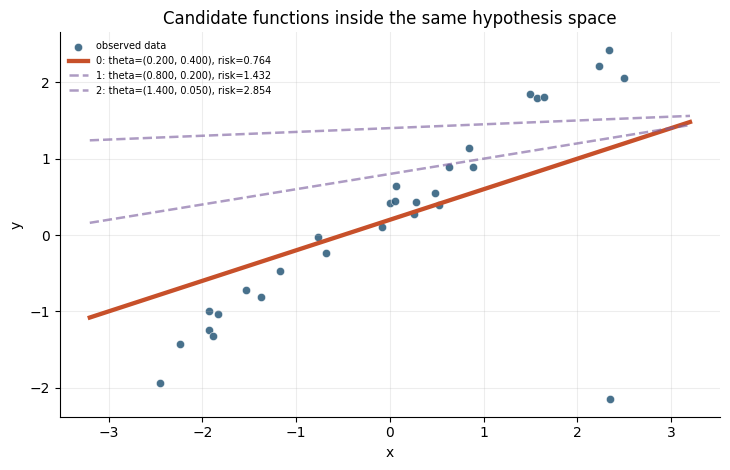

Active theta = [0.2 0.4]
Empirical risk = 0.764
Changed ingredient: selected candidate inside fixed H


In [36]:
# Change these values, then rerun this cell.
seed = 11
outlier = True
candidate_thetas = [
    (0.2, 0.4),
    (0.8, 0.2),
    (1.4, 0.05),
]
active_candidate = 0

result = plot_candidate_selection_example(
    seed=seed,
    outlier=outlier,
    candidate_thetas=candidate_thetas,
    active_candidate=active_candidate,
)


### Plot interpretation

The plotted candidates are all available inside the same $\mathcal{H}$. The data provide evidence about how each candidate behaves on observed points, but the data do not automatically declare one of them to be the trained model.

It should be read as:

$$
\mathcal{D}\text{ provides evidence, while }\mathcal{O}\text{ selects among candidates.}
$$

### Takeaway

The first optimisation limit is **selection**.

A selected solution has the form:

$$
s=h_{\widehat{\theta}}.
$$

At this point, $\widehat{\theta}$ is just the parameter value selected by some rule. The rest of the notebook opens up that rule.

The practical question is:

$$
\text{Which member of }\mathcal{H}\text{ did training select, and why?}
$$


<br>

## 2. How Do We Evaluate a Fit?

### Motivation

Once a function has been selected for inspection, we need a way to evaluate how good its fit is. The residual at observation $i$ is:

$$
r_i=h_{\theta}(x_i)-y_i.
$$

A loss function turns that residual into a penalty:

$$
\ell(r_i)\geq 0.
$$

This section asks:

$$
\text{How do we evaluate how good a selected function's fit is?}
$$

### Minimal example

The plot holds one selected line fixed and shows how its residuals become penalties. Change `theta_selected` to inspect a different selected function, and change `loss_name` to change the evaluation rule.

Look for the difference between:

- residuals in data space;
- pointwise penalties assigned to those residuals;
- the empirical risk that summarises the selected function's fit.


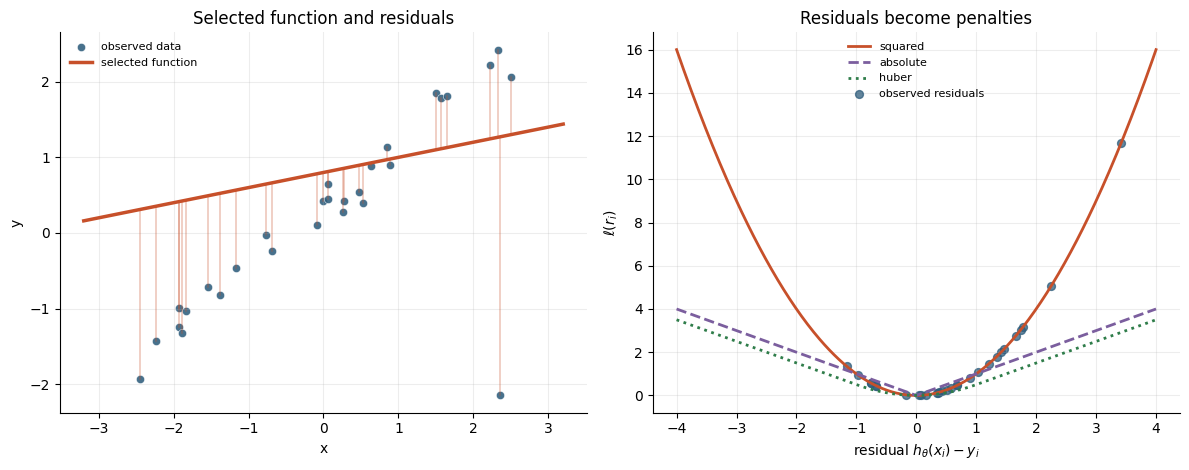

Evaluation loss = squared
Selected theta = [0.8 0.2]
Empirical risk = 1.432
Largest absolute residual = 3.420
Changed ingredient: evaluation rule for a selected function


In [37]:
# Change these values, then rerun this cell.
seed = 11
outlier = True
theta_selected = (0.8, 0.2)
loss_name = "squared"  # "squared", "absolute", or "huber"
huber_delta = 1.0

result = plot_fit_evaluation_example(
    seed=seed,
    outlier=outlier,
    theta_selected=theta_selected,
    loss_name=loss_name,
    huber_delta=huber_delta,
)


### Plot interpretation

The selected line is a member of $\mathcal{H}$. The vertical segments show residuals. The penalty curve shows how the chosen loss converts residual magnitude into a scalar cost.

Squared loss gives large residuals disproportionate influence. Absolute loss is less dominated by large residuals. Huber loss behaves quadratically near zero and more linearly for large residuals.

It should be read as:

$$
\text{fit quality is measured through an explicit evaluation rule.}
$$

### Takeaway

The second optimisation limit is **evaluation**.

The empirical risk of a selected function is:

$$
\widehat{R}_{\mathcal{D}}(h_{\theta})
=
\frac{1}{n}\sum_{i=1}^{n}\ell(h_{\theta}(x_i)-y_i).
$$

Changing the loss can change the operational meaning of a good fit.

The practical question is:

$$
\text{Does this evaluation rule match the research claim?}
$$


<br>

## 3. What Objective Is Being Minimized?

### Motivation

A loss evaluates one residual. An empirical risk averages losses over the dataset. An objective combines that risk with any additional penalty or preference:

$$
J(\theta)=\widehat{R}_{\mathcal{D}}(h_{\theta})+\lambda\Omega(\theta).
$$

Training often uses this scalar quantity to rank candidate parameter values.

This section asks:

$$
\text{What scalar quantity is training trying to make small?}
$$

### Minimal example

The plot evaluates one manually chosen parameter value. Change `theta0_manual` and `theta1_manual` to move the line, and change `loss_name` or `lambda_ridge` to change the objective.

Look for the difference between:

- a visually plausible line;
- its empirical risk;
- its penalty;
- its total objective value.


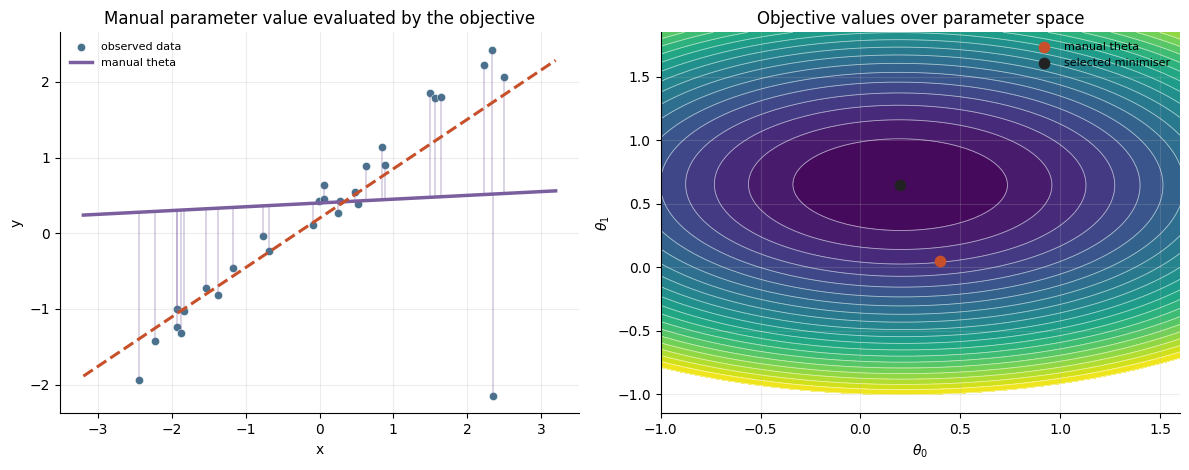

Manual theta = (0.400, 0.050)
Empirical risk = 1.463
Penalty = 0.000
Objective J(theta) = 1.463


In [38]:
# Change these values, then rerun this cell.
seed = 11
outlier = True
theta0_manual = 0.4
theta1_manual = 0.05
loss_name = "squared"  # "squared", "absolute", or "huber"
lambda_ridge = 0.0
huber_delta = 1.0

result = plot_objective_example(
    seed=seed,
    outlier=outlier,
    theta0_manual=theta0_manual,
    theta1_manual=theta1_manual,
    loss_name=loss_name,
    lambda_ridge=lambda_ridge,
    huber_delta=huber_delta,
)


### Plot interpretation

A parameter value is not good or bad by itself. It is evaluated by the objective. The same line can look plausible visually while scoring poorly if the residuals or penalty make it costly.

It should be read as:

$$
\widehat{\theta}\in\operatorname*{arg\,min}_{\theta\in\Theta}J(\theta)
$$

when the optimiser actually reaches the minimiser.

### Takeaway

The third optimisation limit is **objective definition**.

The objective is the formal selection criterion, but a real training run may return only an approximate finite-time solution:

$$
\theta_0,\theta_1,\ldots,\theta_T,
\qquad
s=h_{\theta_T}.
$$

The practical question is:

$$
\text{What objective selected this solution?}
$$


<br>

## 4. Why Move Beyond Least Squares?

### Motivation

For squared-loss linear regression, least squares gives a direct solution. In matrix form,

$$
J(\theta)=\frac{1}{n}\|X\theta-y\|_2^2,
$$

and the unregularised normal equations give a closed-form benchmark when $X^\top X$ is invertible:

$$
\widehat{\theta}_{\mathrm{LS}}=(X^\top X)^{-1}X^\top y.
$$

That direct solution is useful, but it is not the general training story. Many objectives do not have a convenient closed form, and large-scale training usually reports a finite-time iterate.

This section asks:

$$
\text{Why treat training as iterative optimisation rather than only solving least squares?}
$$

### Minimal example

The plot compares the direct least-squares solution with a finite-step gradient descent run on the same squared-loss objective. Change `learning_rate` and `num_steps` to see when the iterative result approaches the direct benchmark.

Look for the difference between:

- the objective's minimiser;
- the path an optimiser follows;
- the finite-time iterate that would actually be reported.


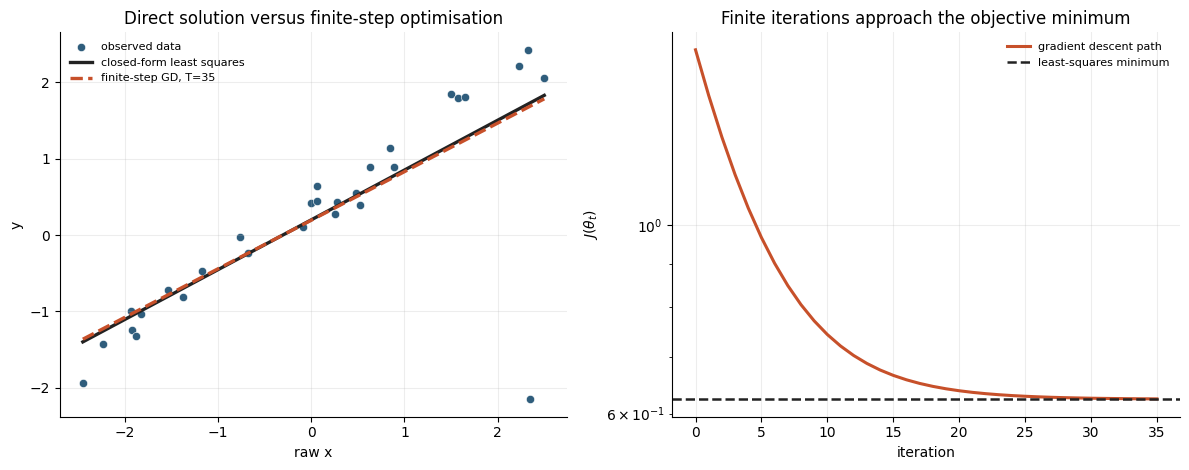

Closed-form least-squares theta = [0.20519164 0.96959436]
Final iterative theta_T = [0.20005537 0.9453239 ]
Distance to least-squares solution = 0.025
Final objective = 0.624
Changed ingredient: optimisation method, from direct solve to iterative path


In [39]:
# Change these values, then rerun this cell.
seed = 11
outlier = True
learning_rate = 0.05
num_steps = 35
theta_init = np.array([0.0, 0.0])
scale_feature = True

result = plot_least_squares_vs_iterative_example(
    seed=seed,
    outlier=outlier,
    learning_rate=learning_rate,
    num_steps=num_steps,
    theta_init=theta_init,
    scale_feature=scale_feature,
)


### Plot interpretation

Least squares jumps directly to the minimiser for this simple objective. Gradient descent instead produces a sequence. With enough stable updates, the finite iterate can approach the least-squares solution; with too few updates or a poor learning rate, the reported solution can differ.

It should be read as:

$$
\text{closed-form least squares is a benchmark, not the whole training procedure.}
$$

### Takeaway

The fourth optimisation limit is **finite training**.

Iterative training selects from a path:

$$
\theta_0,\theta_1,\ldots,\theta_T.
$$

The practical question is:

$$
\text{Is the reported solution the objective minimiser, or a finite-time approximation?}
$$


<br>

## 5. How Does Gradient Descent Select an Iterate?

### Motivation

Gradient descent turns an objective into a sequence of local updates:

$$
\theta_{t+1}=\theta_t-\eta\nabla J(\theta_t).
$$

At each step, the gradient is evaluated at the current parameter value. For the two-parameter model in this notebook,

$$
J(\theta)=\frac{1}{n}\|X\theta-y\|_2^2,
\qquad r(\theta)=X\theta-y,
$$

so

$$
\nabla J(\theta)=\frac{2}{n}X^\top r(\theta).
$$

The intercept component averages the signed residuals. The slope component averages residuals weighted by the input coordinate, so points at larger scaled $x$ values pull more strongly on the slope direction.

The learning rate $\eta$ controls the update size. Training does not directly move through the plotted function space; it moves through parameter space and changes the realised function as a consequence. In the contour plot, each arrow is the parameter-space displacement $\Delta\theta_t=-\eta\nabla J(\theta_t)$.

This section asks:

$$
\text{What path does gradient descent follow?}
$$

### Minimal example

The plot uses the same two-parameter linear objective and shows the gradient descent path over the objective landscape. Change only `learning_rate` while holding the dataset, objective, start, and number of updates fixed.

The helper implements the same loop conceptually as:

```text
theta = theta_init
record theta and J(theta)
for t in range(T):
    residual = X @ theta - y
    grad = (2 / n) * X.T @ residual
    theta = theta - eta * grad
    record theta and J(theta)
```

Try:

```python
learning_rate = 0.005   # slow
learning_rate = 0.05    # stable
learning_rate = 0.5     # unstable or oscillatory
```

Look for the difference between a stable path, a slow path, and an overshooting path.


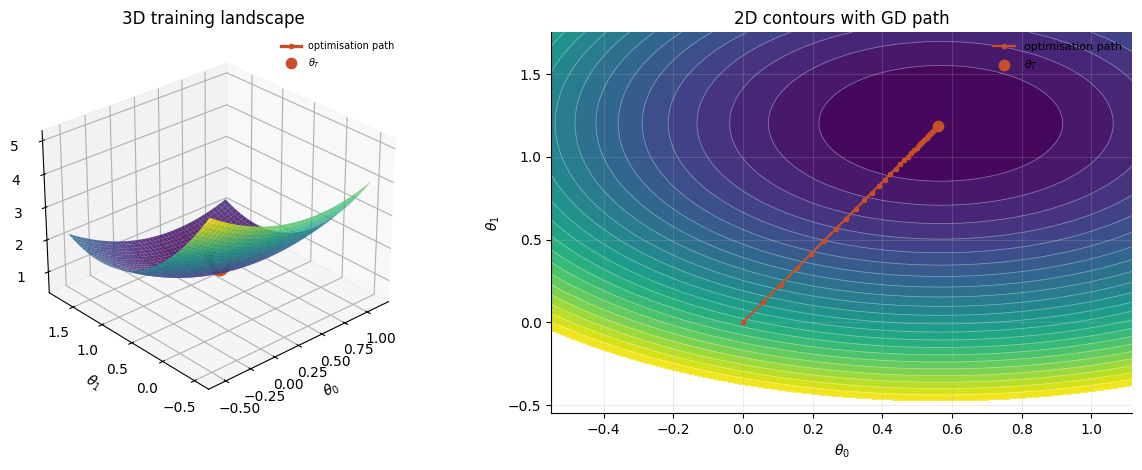

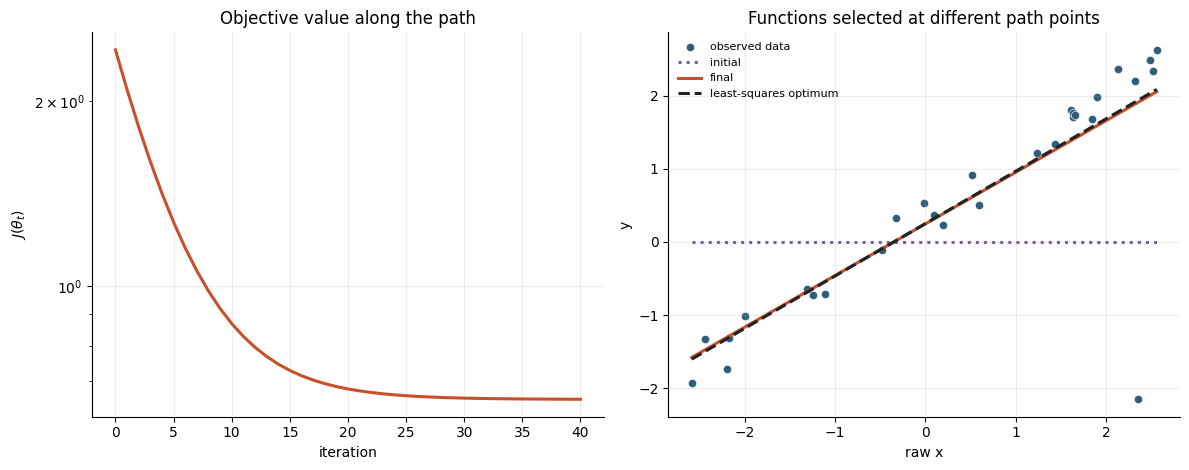

Learning rate = 0.05
Number of steps = 40
Final theta_T = [0.55942362 1.18486839]
Final objective = 0.655
Changed ingredient: O, via update size


In [40]:
# Change these values, then rerun this cell.
seed = 13
learning_rate = 0.05
num_steps = 40
theta_init = np.array([0.0, 0.0])
scale_feature = True

result = plot_gradient_descent_example(
    seed=seed,
    learning_rate=learning_rate,
    num_steps=num_steps,
    theta_init=theta_init,
    scale_feature=scale_feature,
)


### Plot interpretation

The same landscape and same start can produce different finite-time solutions when the learning rate changes. A small learning rate may be safe but slow. A large learning rate may overshoot, oscillate, or diverge.

Read each point on the path as a candidate line $h_{\theta_t}$. The contour panel shows where that parameter value sits on the objective surface; the data-space line changes because the intercept and slope have changed. The loss trace decreases when the local update points downhill enough for the chosen step size.

It should be read as:

$$
\text{the update rule and learning rate are part of }\mathcal{O}.
$$

### Takeaway

The fifth optimisation limit is **path dependence**.

For squared-loss linear regression,

$$
\nabla J(\theta)=\frac{2}{n}X^\top(X\theta-y).
$$

Even when a unique optimum exists, finite training reports an iterate on the path. The reported solution depends on the start $\theta_0$, the step size $\eta$, and the stopping time $T$.

The practical question is:

$$
\text{Did training reach the solution implied by the objective?}
$$


<br>

## 6. What Landscape Does the Optimiser See?

### Motivation

Optimisers search in parameter coordinates. Feature scaling and parameterisation can change the shape of the objective landscape even when the underlying prediction task is essentially the same.

For squared-loss linear regression,

$$
\nabla^2J(\theta)=\frac{2}{n}X^\top X.
$$

Rescaling features changes $X^\top X$, so it changes the curvature seen by the optimiser.

This section asks:

$$
\text{What geometry does training search through?}
$$

### Minimal example

The plot fits the same linear relationship with unscaled and scaled coordinates. Change `scale_feature` from `False` to `True` and compare the objective contours.

Look for the difference between:

- the fitted line in raw data space;
- the parameter coordinates used by the optimiser;
- the condition number of $X^\top X$.


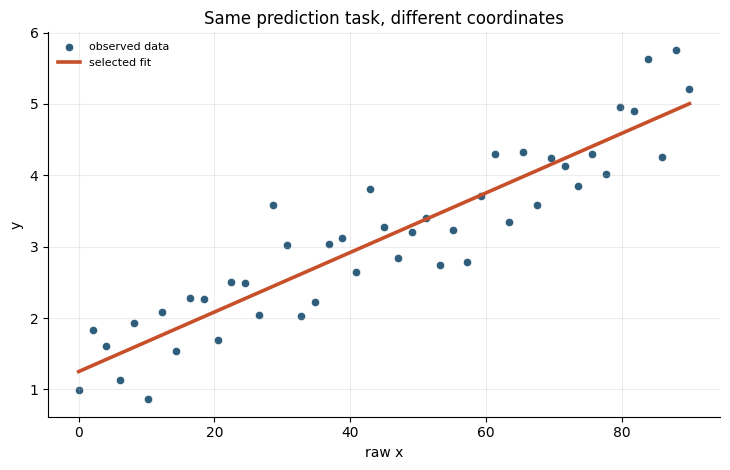

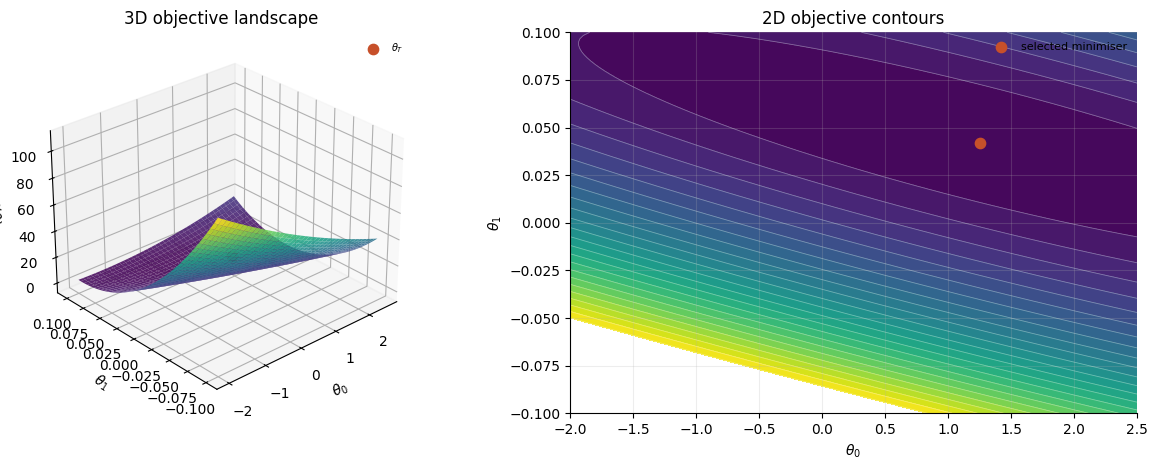

Feature scaled = False
Condition number of X^T X = 10572.29
Changed ingredient: O's coordinate geometry


In [41]:
# Change these values, then rerun this cell.
seed = 19
scale_feature = False
theta0_range = (-2.0, 2.5)
theta1_range = (-0.1, 0.1)
grid_size = 120
manual_theta = None

result = plot_landscape_geometry_example(
    seed=seed,
    scale_feature=scale_feature,
    theta0_range=theta0_range,
    theta1_range=theta1_range,
    grid_size=grid_size,
    manual_theta=manual_theta,
)


### Plot interpretation

The prediction problem can be essentially the same while the optimiser sees a different landscape. Unscaled features often create stretched contours. Scaled features often produce a more balanced landscape.

It should be read as:

$$
\text{scaling changes the geometry of finite optimisation.}
$$

### Takeaway

The sixth optimisation limit is **coordinate geometry**.

The landscape is not just a picture. It is the scalar surface and curvature structure that the optimiser searches.

The practical question is:

$$
\text{What parameter geometry did training actually use?}
$$


<br>

## 7. How Do Curvature and Conditioning Affect the Path?

### Motivation

A learning rate that works in one direction may be too large or too small in another. For a quadratic objective,

$$
J(\theta)=\frac{1}{2}(\theta-\theta^\star)^\top A(\theta-\theta^\star),
$$

with symmetric positive definite $A$, gradient descent updates errors as:

$$
\theta_{t+1}-\theta^\star=(I-\eta A)(\theta_t-\theta^\star).
$$

In an eigen-direction of $A$ with curvature $\lambda_j$, the scalar error is multiplied by $1-\eta\lambda_j$ each step. Values near $1$ mean slow progress, negative values mean oscillation, and magnitude greater than $1$ means divergence in that direction.

This section asks:

$$
\text{Which directions are easy or hard for the optimiser?}
$$

### Minimal example

The plot compares gradient descent on a well-conditioned and ill-conditioned quadratic. Change `lambda_max` while holding the start point, learning rate, and number of updates fixed.

Try:

```python
lambda_max = 5.0    # well-conditioned
lambda_max = 80.0   # ill-conditioned
```

Look for directions that make fast progress and directions that remain under-trained.


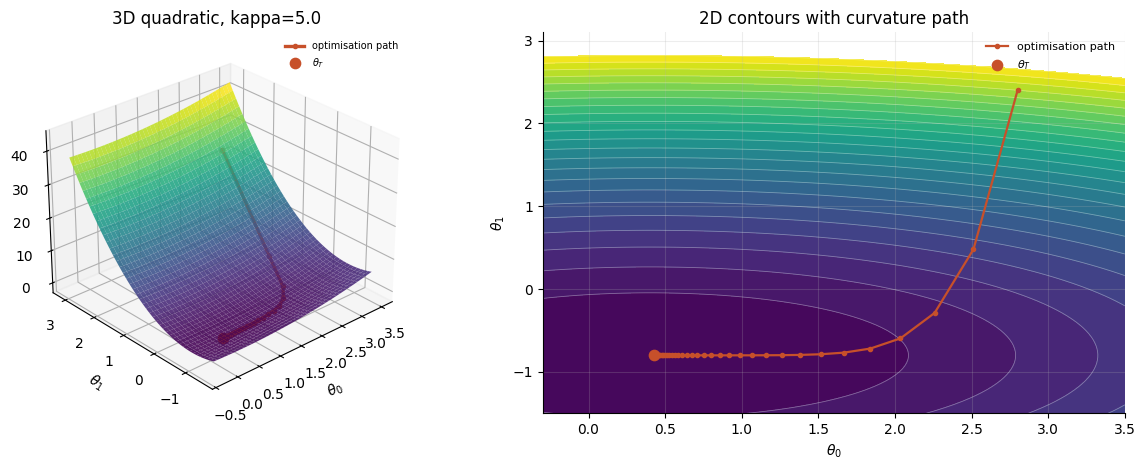

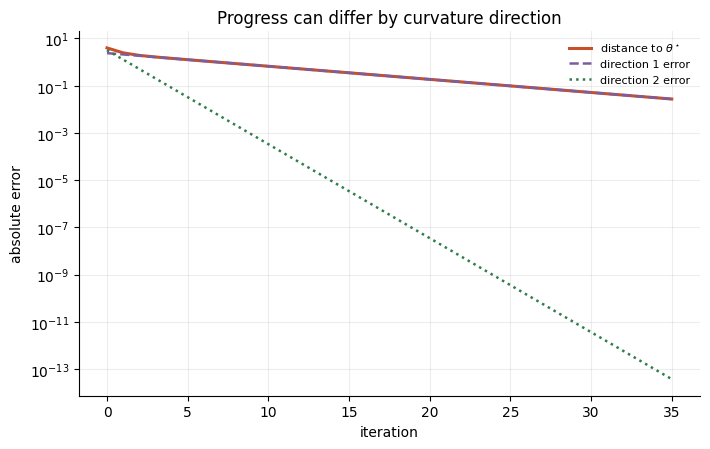

Condition number kappa = 5.00
Learning rate = 0.12
Final distance to theta_star = 0.027


In [42]:
# Change these values, then rerun this cell.
lambda_min = 1.0
lambda_max = 5.0
learning_rate = 0.12
num_steps = 35
theta_init = np.array([2.8, 2.4])
theta_star = np.array([0.4, -0.8])

result = plot_conditioning_example(
    lambda_min=lambda_min,
    lambda_max=lambda_max,
    learning_rate=learning_rate,
    num_steps=num_steps,
    theta_init=theta_init,
    theta_star=theta_star,
)


### Plot interpretation

In a well-conditioned landscape, progress can occur at a compatible rate in both directions. In an ill-conditioned landscape, one direction may move quickly while another remains under-trained or oscillatory.

It should be read as:

$$
\kappa(A)=\frac{\lambda_{\max}(A)}{\lambda_{\min}(A)}
$$

summarises how stretched the quadratic is.

### Takeaway

The seventh optimisation limit is **conditioning**.

For a quadratic, stable convergence requires:

$$
0<\eta<\frac{2}{\lambda_{\max}(A)}.
$$

The practical question is:

$$
\text{Did the optimiser have enough time and suitable geometry to move in the directions that matter?}
$$


<br>

## 8. What Changes When Updates Are Stochastic?

### Motivation

Minibatches are often introduced as a computational shortcut. They also change the realised training path.

Full-batch gradient descent uses every observation:

$$
\nabla J(\theta)=\frac{1}{n}\sum_{i=1}^{n}\nabla_\theta\ell(h_\theta(x_i),y_i).
$$

Minibatch stochastic gradient descent uses a subset $B_t$:

$$
g_t=\frac{1}{|B_t|}\sum_{i\in B_t}\nabla_\theta\ell(h_\theta(x_i),y_i).
$$

This section asks:

$$
\text{How does stochasticity shape the selected solution?}
$$

### Minimal example

The plot keeps the full-data objective as the reference surface and compares a full-batch path with several minibatch paths. Change `batch_size` and `num_repeats` to inspect variability.

Try:

```python
batch_size = 80   # full batch
batch_size = 16
batch_size = 4
```

Look for noisy paths and seed-to-seed variation in final parameters.


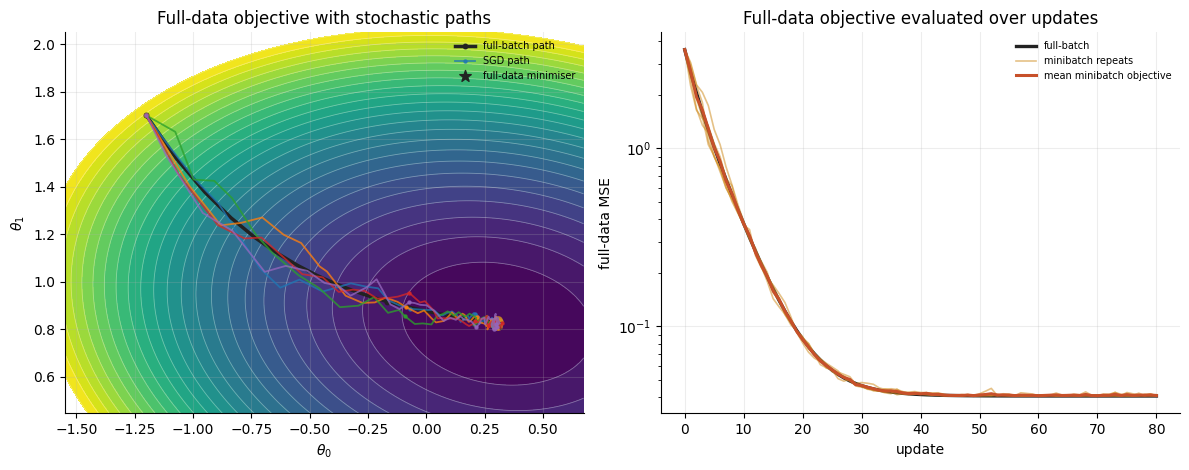

| Repeat | Final theta | Final full-data objective |
|---|---|---|
| 0 | [0.307, 0.813] | 0.04088 |
| 1 | [0.304, 0.822] | 0.04065 |
| 2 | [0.311, 0.831] | 0.04087 |
| 3 | [0.305, 0.840] | 0.04136 |
| 4 | [0.304, 0.829] | 0.04074 |

Batch size = 8
Number of repeats = 5
Mean final objective = 0.041
Std final objective = 0.000
Changed ingredient: O, via stochastic update path


In [43]:
# Change these values, then rerun this cell.
seed = 41
batch_size = 8
learning_rate = 0.05
num_updates = 80
num_repeats = 5
shuffle_each_epoch = True

result = plot_stochastic_updates_example(
    seed=seed,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_updates=num_updates,
    num_repeats=num_repeats,
    shuffle_each_epoch=shuffle_each_epoch,
)


### Plot interpretation

Full-batch gradient descent follows a smooth path through the full-data objective. Minibatch paths are noisier. Different random seeds can reach different finite-time parameter values.

It should be read as:

$$
\mathbb{E}[g_t\mid\theta_t]=\nabla J(\theta_t),
\qquad
\operatorname{Var}(g_t\mid\theta_t)>0.
$$

An unbiased gradient estimate can still produce seed-dependent realised solutions.

### Takeaway

The eighth optimisation limit is **stochasticity**.

The selected model is an outcome of a random training process.

The practical question is:

$$
\text{How variable is the selected solution across seeds and batches?}
$$


<br>

## 9. What Preference Does Regularisation Add?

### Motivation

Regularisation is not just an anti-overfitting trick. It is an explicit preference among solutions.

For ridge regression,

$$
J_\lambda(\theta)=\frac{1}{n}\|X\theta-y\|_2^2+\lambda\|\theta\|_2^2.
$$

The penalty changes the objective, so it changes the selection rule.

This section asks:

$$
\text{Which compatible solution does the penalty prefer?}
$$

### Minimal example

The plot uses the same observed dataset and linear hypothesis space while changing only `lambda_ridge`. Compare the selected line, the objective contours, training error, validation error, and parameter norm.

Try:

```python
lambda_ridge = 0.0
lambda_ridge = 0.01
lambda_ridge = 0.1
lambda_ridge = 1.0
```

Look for the difference between empirical fit and the penalty's preference for smaller parameter norms.


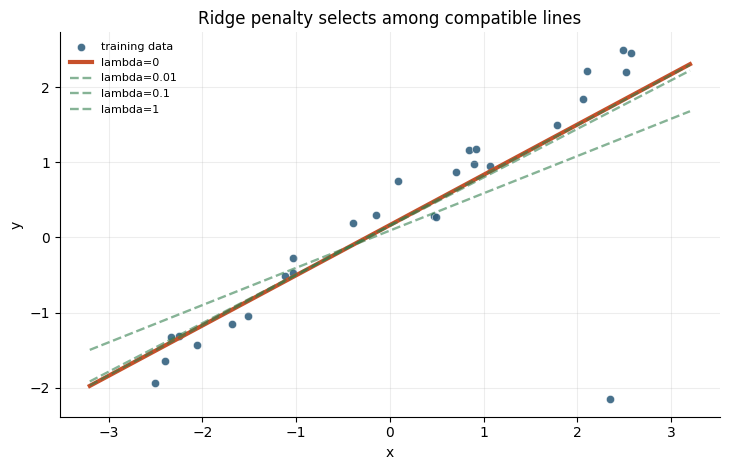

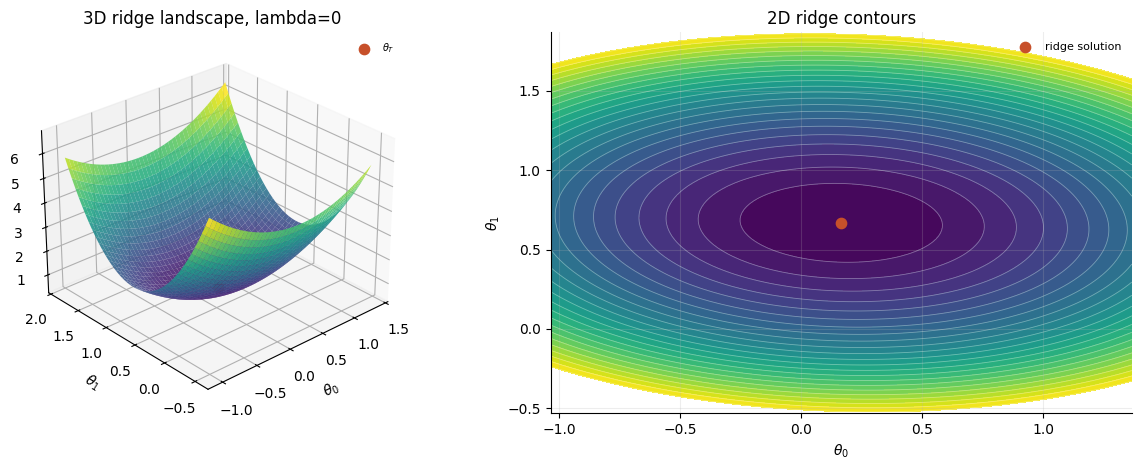

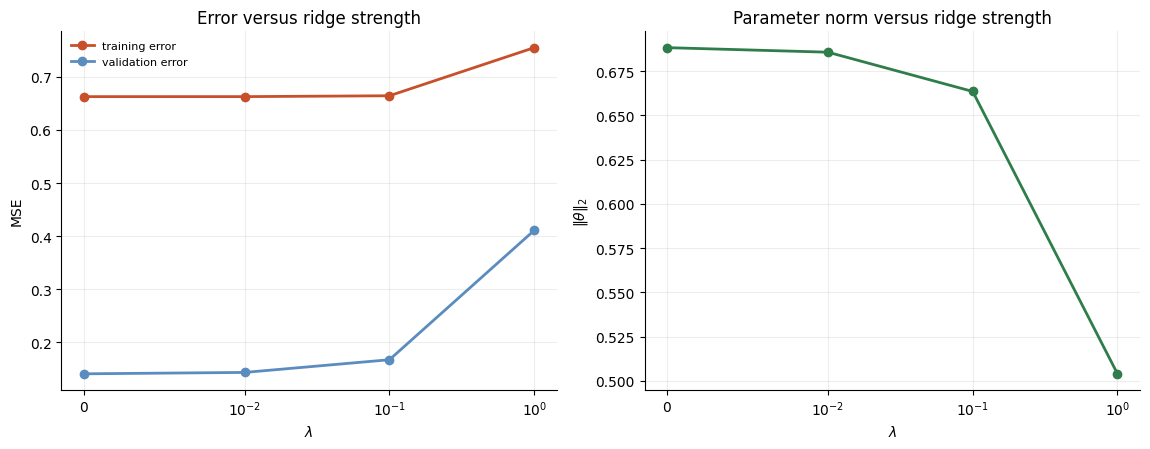

| lambda | theta | Training error | Validation error | Parameter norm | Preference |
|---|---|---|---|---|---|
| 0 | [0.165, 0.668] | 0.6628 | 0.1408 | 0.6883 | least constrained fit |
| 0.01 | [0.164, 0.666] | 0.6628 | 0.1435 | 0.6857 | smoother compatible fit |
| 0.1 | [0.153, 0.646] | 0.6644 | 0.1674 | 0.6635 | strong norm preference |
| 1 | [0.092, 0.496] | 0.755 | 0.411 | 0.504 | strong norm preference |

lambda = 0.0
Selected theta = [0.1654194  0.66807845]
Training error = 0.663
Validation error = 0.141
Parameter norm = 0.688


In [44]:
# Change these values, then rerun this cell.
seed = 31
outlier = True
lambda_ridge = 0.0
validation_seed = 32
lambda_values = [0.0, 0.01, 0.1, 1.0]

result = plot_regularisation_example(
    seed=seed,
    outlier=outlier,
    lambda_ridge=lambda_ridge,
    validation_seed=validation_seed,
    lambda_values=lambda_values,
)


### Plot interpretation

Increasing $\lambda$ changes the objective. The selected line may fit the observed points less aggressively, especially if an outlier would require a large coefficient.

Training error, validation error, and coefficient norm answer different questions.

It should be read as:

$$
\widehat{\theta}_\lambda=(X^\top X+n\lambda I)^{-1}X^\top y
$$

for squared-loss ridge regression.

### Takeaway

The ninth optimisation limit is **preference**.

Regularisation declares what kind of solution should be selected when empirical fit alone is not enough.

The practical question is:

$$
\text{What preference did the penalty encode, and is that preference justified by the research claim?}
$$


<br>

## 10. Where Can Initialisation Matter?

### Motivation

In non-convex optimisation, the starting point can affect which basin the optimiser reaches. A single seed may not represent the training procedure.

A non-convex objective may contain many local minima, saddle points, flat regions, and symmetries:

$$
J(\theta)=\frac{1}{n}\sum_{i=1}^{n}\ell(h_\theta(x_i),y_i).
$$

Training starts from:

$$
\theta_0\sim P_{\mathrm{init}}.
$$

This section asks:

$$
\text{How much does the selected solution depend on the start?}
$$

### Minimal example

The plot uses a toy two-parameter non-convex objective so the landscape can be drawn directly. Hold the objective, learning rate, and update rule fixed. Change only the initial points.

Look for the difference between:

- different starting points;
- different basins;
- final parameter values that may represent different behaviour elsewhere.


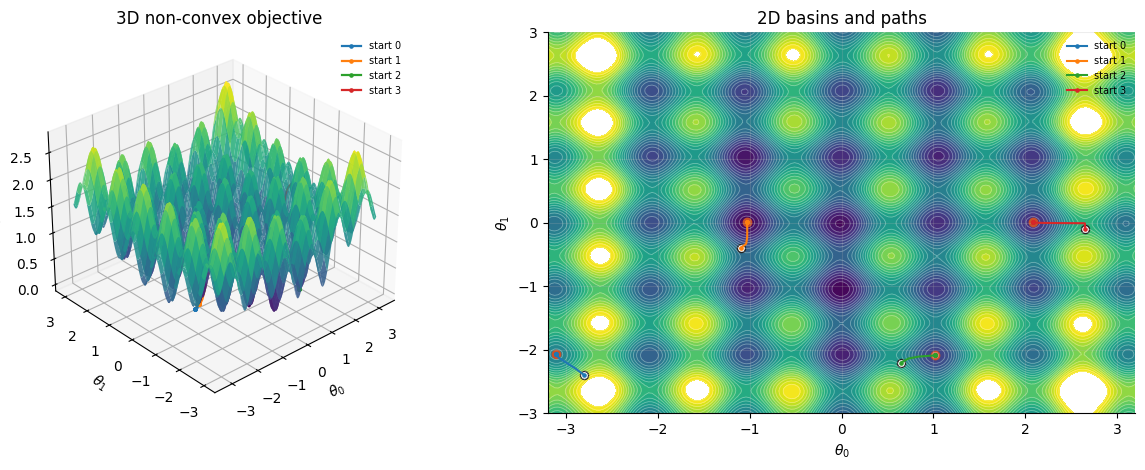

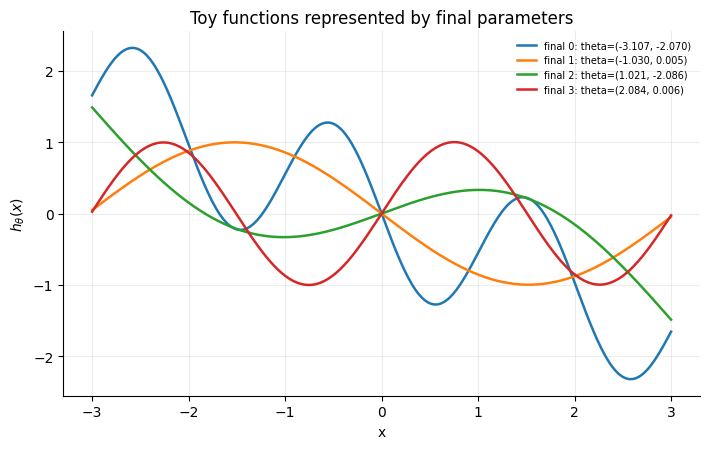

| Start | theta_0 | theta_T | Final objective |
|---|---|---|---|
| 0 | [-2.800, -2.400] | [-3.107, -2.070] | 0.9075 |
| 1 | [-1.100, -0.400] | [-1.030, 0.005] | -0.04507 |
| 2 | [0.650, -2.200] | [1.021, -2.086] | 0.3445 |
| 3 | [2.650, -0.100] | [2.084, 0.006] | 0.2199 |

Number of starts = 4
Final objective values:
| Start | theta_0 | theta_T | Final objective |
|---|---|---|---|
| 0 | [-2.800, -2.400] | [-3.107, -2.070] | 0.9075 |
| 1 | [-1.100, -0.400] | [-1.030, 0.005] | -0.04507 |
| 2 | [0.650, -2.200] | [1.021, -2.086] | 0.3445 |
| 3 | [2.650, -0.100] | [2.084, 0.006] | 0.2199 |
Changed ingredient: O, via initialisation


In [45]:
# Change these values, then rerun this cell.
seed = 7
learning_rate = 0.045
num_steps = 120
start_points = [
    (-2.8, -2.4),
    (-1.1, -0.4),
    (0.65, -2.2),
    (2.65, -0.1),
]

result = plot_initialisation_example(
    seed=seed,
    learning_rate=learning_rate,
    num_steps=num_steps,
    start_points=start_points,
)


### Plot interpretation

Different starts can fall into different basins. Some final parameters may have similar objective values but imply different behaviour away from the observed training points.

It should be read as:

$$
\theta_T^{(1)}\neq\theta_T^{(2)}
$$

can occur even when $\mathcal{D}$, $\mathcal{H}$, the objective, and the update rule are fixed.

### Takeaway

The tenth optimisation limit is **initialisation**.

Seed sensitivity is evidence about the training procedure, not just a nuisance detail.

The practical question is:

$$
\text{Does the reported solution persist across reasonable initialisations?}
$$


<br>

## 11. Which Iterate Is Reported?

### Motivation

Training normally returns a finite-time model, not an exact global minimiser. The stopping rule decides which point on the path becomes the reported solution.

Training produces:

$$
\theta_0,\theta_1,\ldots,\theta_T.
$$

A validation-based stopping rule is:

$$
T^\star=\arg\min_{t\in\{0,\ldots,T_{\max}\}}\widehat{R}_{\mathrm{val}}(h_{\theta_t}).
$$

This section asks:

$$
\text{Which iterate becomes }s?
$$

### Minimal example

The plot follows one trajectory and compares early, validation-selected, and late iterates. Change `selected_step` to report a different point on the same path.

Try:

```python
selected_step = "early"
selected_step = "validation"
selected_step = "late"
selected_step = 40
```

Look for cases where training loss continues to fall while validation loss stops improving.


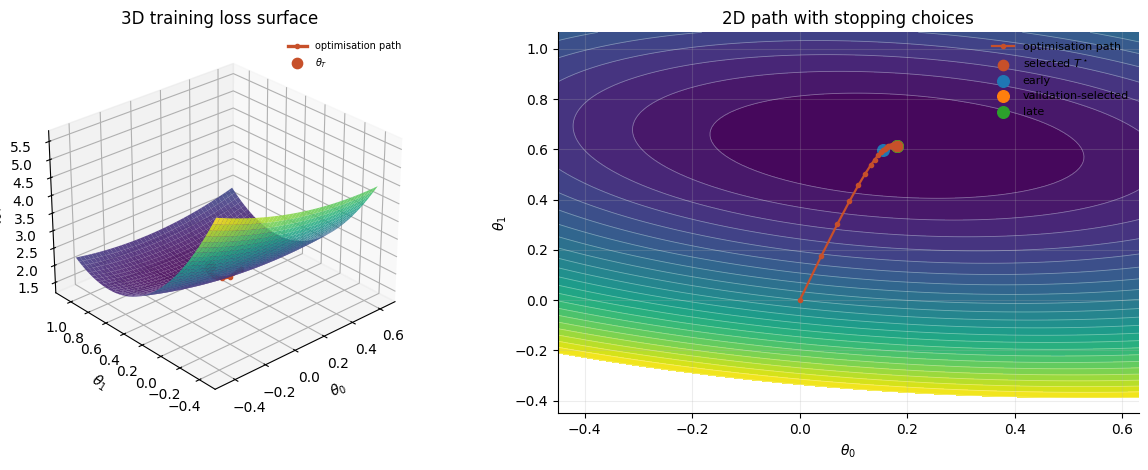

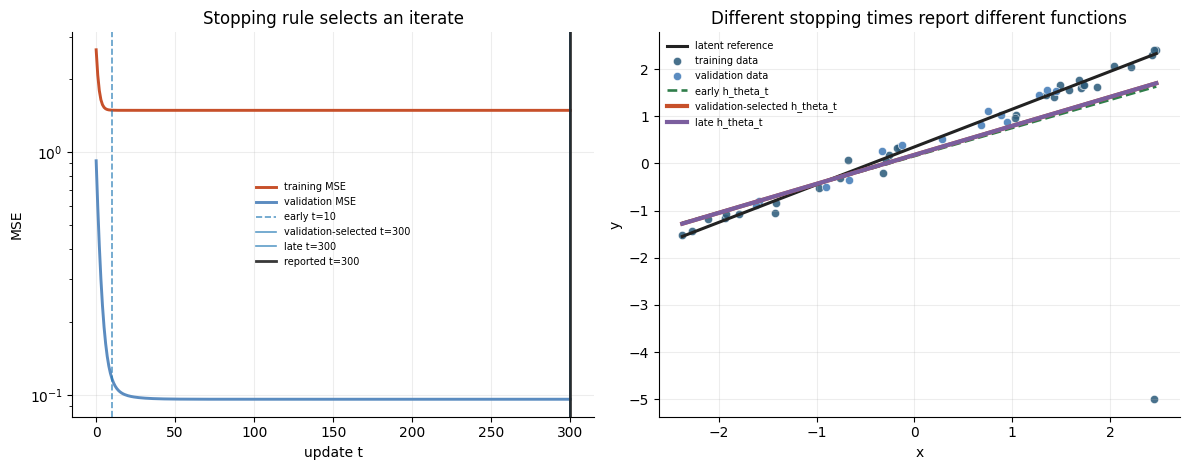

| Stopping rule | t | Training MSE | Validation MSE | theta_t |
|---|---|---|---|---|
| early | 10 | 1.491 | 0.1166 | [0.154, 0.596] |
| validation-selected | 300 | 1.489 | 0.09589 | [0.181, 0.614] |
| late | 300 | 1.489 | 0.09589 | [0.181, 0.614] |
| reported | 300 | 1.489 | 0.09589 | [0.181, 0.614] |

Selected stopping rule = validation
T_star = 300
Training error at T_star = 1.489
Validation error at T_star = 0.096
Changed ingredient: O, via stopping rule


In [46]:
# Change these values, then rerun this cell.
seed = 42
learning_rate = 0.05
max_steps = 300
validation_fraction = 0.3
selected_step = "validation"  # "early", "validation", "late", or an integer

result = plot_stopping_rule_example(
    seed=seed,
    learning_rate=learning_rate,
    max_steps=max_steps,
    validation_fraction=validation_fraction,
    selected_step=selected_step,
)


### Plot interpretation

Training loss may keep falling while validation loss stops improving. Different stopping times select different functions from the same trajectory.

It should be read as:

$$
s=h_{\theta_{T^\star}}.
$$

The stopping rule is therefore part of the selection procedure.

### Takeaway

The eleventh optimisation limit is **stopping**.

Stopping must be reported as part of the evidence behind the trained model.

The practical question is:

$$
\text{Why was this iterate selected rather than an earlier or later one?}
$$


<br>

## 12. How Do We Audit the Optimisation Procedure?

### Motivation

The final audit turns the notebook into a checklist for interpreting trained models. Optimisation maps data and candidates to a selected solution:

$$
\mathcal{O}:(\mathcal{H},\mathcal{D})\mapsto s.
$$

In practice, $\mathcal{O}$ includes:

$$
\text{loss}
+
\text{regularisation}
+
\text{initialisation}
+
\text{update rule}
+
\text{stochasticity}
+
\text{stopping rule}.
$$

This section asks:

$$
\text{Which part of }\mathcal{H}+\mathcal{D}+\mathcal{O}\text{ explains the observed behaviour?}
$$

### Minimal example

Change `scenario` to focus the audit table on a particular observed behaviour.


In [47]:
# Change these values, then rerun this cell.
scenario = "high_train_error"

# Options:
# scenario = "high_train_error"
# scenario = "good_train_bad_shift"
# scenario = "seed_sensitive"
# scenario = "regularisation_sensitive"
# scenario = "early_stopping_sensitive"
# scenario = "loss_sensitive"
# scenario = "iterative_not_converged"

result = display_optimisation_audit(scenario=scenario)


| Observation | Likely source | What to check |
|---|---|---|
| High training error | $\mathcal{H}$ or $\mathcal{O}$ | capacity, optimisation path |
| Same $\mathcal{D}$ and $\mathcal{H}$, different solutions | $\mathcal{O}$ | loss, seed, batch size, stopping |
| Good random-test error, bad shifted-context error | $\mathcal{D}$ or deployment mismatch | validation design |
| Strong sensitivity to $\lambda$ | $\mathcal{O}$ | regularisation preference |
| Training loss keeps falling, validation worsens | $\mathcal{O}$ | stopping rule |
| Finite-step optimiser differs from least-squares benchmark | $\mathcal{O}$ | learning rate, steps, scaling, convergence |

**Selected scenario:** `high_train_error`

| Observation | Likely source | What to check |
|---|---|---|
| High training error | $\mathcal{H}$ or $\mathcal{O}$ | capacity, optimisation path |

### Plot interpretation

The table separates common observations from likely sources. Two learners can share the same data and hypothesis space but select different solutions:

$$
(\mathcal{H},\mathcal{D},\mathcal{O}_1)\rightarrow s_1,
\qquad
(\mathcal{H},\mathcal{D},\mathcal{O}_2)\rightarrow s_2.
$$

The audit should not be read as a recipe for choosing one universally best optimiser. It should be read as a way to identify which selection choices matter for a research claim.

### Takeaway

The core lesson is not that one optimiser is always better. The lesson is that training is a selection procedure.

The final audit is:

$$
\text{What objective was minimised?}
$$

$$
\text{What geometry was searched?}
$$

$$
\text{What path was followed?}
$$

$$
\text{Which rule selected the reported iterate?}
$$

$$
\text{Does that selected solution support the research claim?}
$$

Connection to the broader course:

$$
\mathcal{D}\text{ provides evidence.}
$$

$$
\mathcal{H}\text{ defines possible functions.}
$$

$$
\mathcal{O}\text{ selects among compatible functions.}
$$
